# feature info
- tm : 시간
- branch_ID : 지사명
- ta : 정시 기온
- wd : 정시 10분 평균 풍향
- ws : 정시 10분 평균 풍속
- rn_day : 일강수량(mm)
- rn_hr1 : 1시간 강수량(mm)
- hm : 정시 상대습도
- si : ASOS 일사량
- ta_chi : 체감온도
- heat_demand: 시간당 지사별 열공급량

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import pandas as pd

In [3]:
df = pd.read_csv('./train_heat.csv', index_col=0)
df.head(30)

,train_heat.tm,train_heat.branch_id,train_heat.ta,train_heat.wd,train_heat.ws,train_heat.rn_day,train_heat.rn_hr1,train_heat.hm,train_heat.si,train_heat.ta_chi,train_heat.heat_demand
1,2021010101,A,-10.1,78.3,0.5,0.0,0.0,68.2,-99.00,-8.2,281
2,2021010102,A,-10.2,71.9,0.6,0.0,0.0,69.9,-99.00,-8.6,262
3,2021010103,A,-10.0,360.0,0.0,0.0,0.0,69.2,-99.00,-8.8,266
4,2021010104,A,-9.3,155.9,0.5,0.0,0.0,65.0,-99.00,-8.9,285
5,2021010105,A,-9.0,74.3,1.9,0.0,0.0,63.5,-99.00,-9.2,283
6,2021010106,A,-9.0,81.9,1.5,0.0,0.0,66.9,-99.00,-9.2,285
7,2021010107,A,-9.0,88.4,1.3,0.0,0.0,64.7,-99.00,-8.4,285
8,2021010108,A,-8.6,88.9,1.2,0.0,0.0,63.8,0.00,-8.4,284
9,2021010109,A,-7.4,71.6,1.3,0.0,0.0,61.2,0.27,-7.5,290
10,2021010110,A,-4.7,157.5,0.5,0.0,0.0,50.4,0.76,-5.3,285


In [5]:
df['train_heat.branch_id'].unique()

array(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M',
       'N', 'O', 'P', 'Q', 'R', 'S'], dtype=object)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 499301 entries, 1 to 499301
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   train_heat.tm           499301 non-null  int64  
 1   train_heat.branch_id    499301 non-null  object 
 2   train_heat.ta           499301 non-null  float64
 3   train_heat.wd           499301 non-null  float64
 4   train_heat.ws           499301 non-null  float64
 5   train_heat.rn_day       499301 non-null  float64
 6   train_heat.rn_hr1       499301 non-null  float64
 7   train_heat.hm           499301 non-null  float64
 8   train_heat.si           499301 non-null  float64
 9   train_heat.ta_chi       499301 non-null  float64
 10  train_heat.heat_demand  499301 non-null  int64  
dtypes: float64(8), int64(2), object(1)
memory usage: 45.7+ MB


In [7]:
df.describe().round(2)
# Null값은 없는데 min값이 이상함

,train_heat.tm,train_heat.ta,train_heat.wd,train_heat.ws,train_heat.rn_day,train_heat.rn_hr1,train_heat.hm,train_heat.si,train_heat.ta_chi,train_heat.heat_demand
count,4.993010e+05,499301.00,499301.00,499301.00,499301.00,499301.00,499301.00,499301.00,499301.00,499301.00
mean,2.022067e+09,10.62,194.32,-2.34,-1.84,-3.65,53.02,-45.60,13.87,95.86
std,8.172155e+05,20.88,118.35,19.16,21.34,19.08,49.08,49.94,11.89,115.27
min,2.021010e+09,-99.00,-99.00,-99.00,-99.00,-99.00,-99.00,-99.00,-99.00,-99.00
25%,2.021100e+09,4.40,105.00,0.50,0.00,0.00,44.90,-99.00,4.40,25.00
50%,2.022070e+09,14.20,212.10,1.10,0.00,0.00,64.70,0.00,15.00,55.00
75%,2.023040e+09,22.50,294.30,2.00,0.00,0.00,82.50,0.96,24.30,116.00
max,2.023123e+09,37.80,360.00,11.90,326.50,92.50,100.00,3.92,37.10,966.00


In [9]:
# -98 이상인 행만 남기기
columns_to_check = df.iloc[:, 2:]

# 선택된 열 범위에서 -98 이하인 데이터가 하나라도 있는 행을 찾기
rows_to_drop_condition = (columns_to_check <= -98).any(axis=1)

# 삭제할 행의 조건이 False인 행들만 선택하여 새로운 DataFrame 생성 (즉, 삭제하지 않을 행)
df2 = df[~rows_to_drop_condition]
print(f'이상한 행 삭제 후 데이터 개수: {len(df2)}')

이상한 행 삭제 후 데이터 개수: 236232


In [125]:
df2.describe()

,train_heat.tm,train_heat.ta,train_heat.wd,train_heat.ws,train_heat.rn_day,train_heat.rn_hr1,train_heat.hm,train_heat.si,train_heat.ta_chi,train_heat.heat_demand
count,2.362320e+05,236232.000000,236232.000000,236232.000000,236232.000000,236232.000000,236232.000000,236232.000000,236232.000000,236232.000000
mean,2.022143e+09,16.512025,205.559196,1.788210,2.222346,0.166312,60.126592,1.102928,16.716615,84.001482
std,7.998975e+05,10.360786,98.541036,1.216687,10.508855,1.267522,21.532097,0.974476,11.278961,99.367904
min,2.021010e+09,-19.600000,-9.900000,0.000000,0.000000,0.000000,2.500000,0.000000,-24.700000,0.000000
25%,2.021111e+09,8.900000,128.200000,0.900000,0.000000,0.000000,43.600000,0.220000,8.300000,25.000000
50%,2.022080e+09,18.400000,223.000000,1.600000,0.000000,0.000000,59.600000,0.860000,18.700000,51.000000
75%,2.023043e+09,24.800000,288.500000,2.400000,0.000000,0.000000,76.900000,1.830000,26.100000,101.000000
max,2.023123e+09,37.800000,360.000000,11.900000,283.700000,73.000000,100.000000,3.920000,37.100000,893.000000


In [11]:
# 지점 별로 데이터 분리
grouped_df = df2.groupby('train_heat.branch_id')
locations = df2['train_heat.branch_id'].unique()

# 각 지점별 데이터프레임을 저장할 딕셔너리
location_dict = {}

# 모든 고유한 branch_id 값을 가져옴
for name in locations:
    location_dict[name] = grouped_df.get_group(name).copy()

# 지점별 데이터 개수 확인
for name in locations:
    print(f'{name} 지점의 데이터 개수 : {len(location_dict[name])}')

A 지점의 데이터 개수 : 14185
B 지점의 데이터 개수 : 12852
C 지점의 데이터 개수 : 14138
D 지점의 데이터 개수 : 8975
E 지점의 데이터 개수 : 8973
F 지점의 데이터 개수 : 12402
G 지점의 데이터 개수 : 13529
H 지점의 데이터 개수 : 13529
I 지점의 데이터 개수 : 12241
J 지점의 데이터 개수 : 13913
K 지점의 데이터 개수 : 12373
L 지점의 데이터 개수 : 14296
M 지점의 데이터 개수 : 14162
N 지점의 데이터 개수 : 11432
O 지점의 데이터 개수 : 14060
P 지점의 데이터 개수 : 4561
Q 지점의 데이터 개수 : 12990
R 지점의 데이터 개수 : 13968
S 지점의 데이터 개수 : 13653


In [23]:
# 지점별 상대도수
origin_cnt = 499301/len(locations)
rel_freq = {}
for name in locations:
    rel_freq[name] =  (len(location_dict[name]))/origin_cnt

rel_freq

{'A': 0.5397846188972183,
 'B': 0.4890597054682446,
 'C': 0.5379961185737662,
 'D': 0.3415274553826249,
 'E': 0.34145134898588225,
 'F': 0.4719357662011492,
 'G': 0.5148217207656304,
 'H': 0.5148217207656304,
 'I': 0.46580920126336617,
 'J': 0.5294341489402185,
 'K': 0.4708322234483808,
 'L': 0.5440085239164352,
 'M': 0.5389093953346779,
 'N': 0.4350241637809658,
 'O': 0.535027969100803,
 'P': 0.17356063777160471,
 'Q': 0.4943110468434872,
 'R': 0.5315270748506412,
 'S': 0.5195403173636745}

0.5 이상인 값의 개수: 10개


<Figure size 600x600 with 0 Axes>

([<matplotlib.patches.Wedge at 0x2428b222c00>,
 [Text(-1.0962429369358824, -0.09083734484335798, '50% 이상'),
  Text(1.0962429284310715, 0.09083744748102804, '50% 미만')],
 [Text(-0.5979506928741176, -0.04954764264183162, '52.6%'),
  Text(0.5979506882351299, 0.04954769862601529, '47.4%')])

Text(0.5, 1.0, '상대도수 50% 기준 비율')

(-1.099999768526657,
 1.0999986564109983,
 -1.0999994314801818,
 1.0999999729276277)

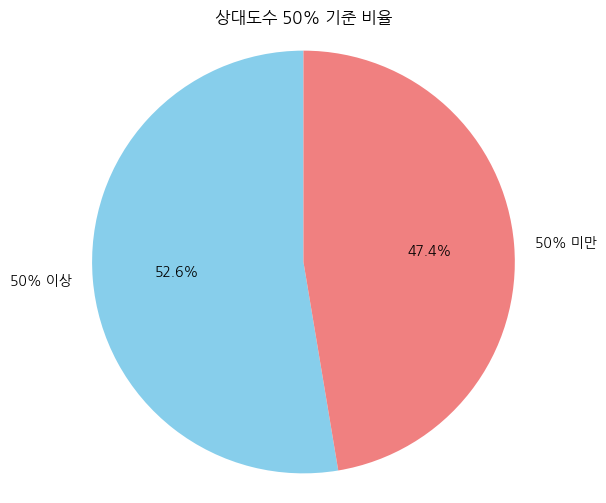

In [39]:
# 지점별 상대도수 - 파이그래프
count = sum(1 for value in rel_freq.values() if value >= 0.5)
print(f"0.5 이상인 값의 개수: {count}개")

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font_path = 'C:\\WINDOWS\\Fonts\\NanumGothic.ttf'
fontprop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = fontprop.get_name()

data = {'50% 이상': 10, '50% 미만': 9}

# 딕셔너리에서 레이블과 값 추출
labels = data.keys()
sizes = data.values()

plt.figure(figsize=(6, 6)) # 그래프 크기 설정
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('상대도수 50% 기준 비율')
plt.axis('equal') # 원형을 유지하도록 설정
plt.show()

<Figure size 1000x600 with 0 Axes>

<Axes: ylabel='Count'>

Text(0.5, 0, '상대도수')

Text(0, 0.5, '개수')

Text(0.5, 1.0, '지점별 데이터 질 분포')

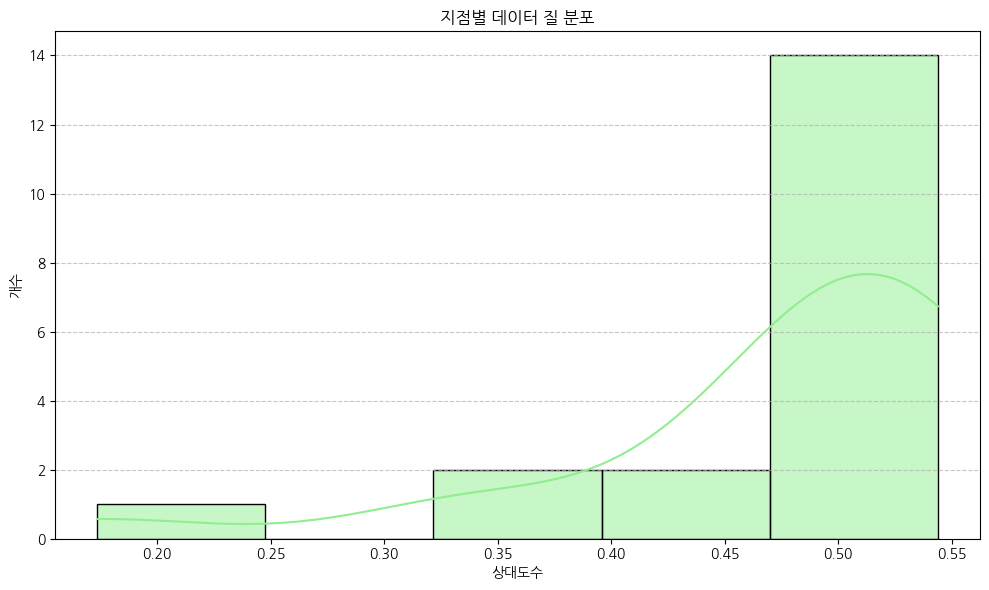

In [47]:
# 지점별 상대도수 - 히스토그램
import seaborn as sns
values = list(rel_freq.values()) # 딕셔너리의 값들만 추출

plt.figure(figsize=(10, 6))
# kde=True: 커널 밀도 추정 곡선 그리기
# rug=True: 각 데이터 포인트의 위치를 x축 아래에 작은 수염으로 표시
sns.histplot(values, bins=5, kde=True, color='lightgreen', edgecolor='black')
# sns.kdeplot(values, fill=True, color='lightgreen') # KDE 플롯만 그릴 수도 있음

plt.xlabel("상대도수")
plt.ylabel("개수")
plt.title("지점별 데이터 질 분포")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

Text(L, 0.5540085239164352, '0.54')

Text(A, 0.5497846188972183, '0.54')

Text(M, 0.5489093953346779, '0.54')

Text(C, 0.5479961185737662, '0.54')

...

Text(0.5, 0, '지점')

Text(0, 0.5, '상대도수')

Text(0.5, 1.0, '각 지점별 데이터 질(상대도수)')

(0.0, 0.6)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
 [Text(0, 0, 'L'),
  Text(1, 0, 'A'),
  Text(2, 0, 'M'),
  Text(3, 0, 'C'),
  Text(4, 0, 'O'),
  Text(5, 0, 'R'),
  Text(6, 0, 'J'),
  Text(7, 0, 'S'),
  Text(8, 0, 'H'),
  Text(9, 0, 'G'),
  Text(10, 0, 'Q'),
  Text(11, 0, 'B'),
  Text(12, 0, 'F'),
  Text(13, 0, 'K'),
  Text(14, 0, 'I'),
  Text(15, 0, 'N'),
  Text(16, 0, 'D'),
  Text(17, 0, 'E'),
  Text(18, 0, 'P')])

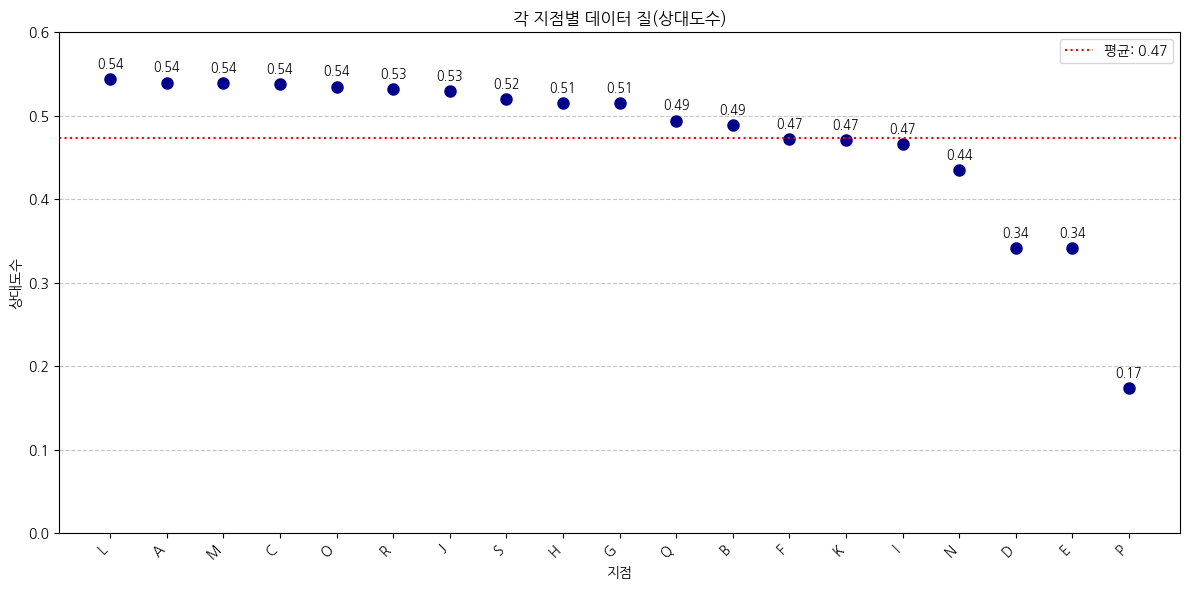

In [49]:
# 지점별 상대도수 - 점 그래프
# 딕셔너리를 Pandas Series로 변환
series_data = pd.Series(rel_freq)

# 값을 기준으로 정렬
series_data = series_data.sort_values(ascending=False)

# 점 그래프 그리기 
plt.figure(figsize=(12, 6)) 
plt.plot(series_data.index, series_data.values, 'o', color='darkblue', markersize=8)

# 각 점 위에 실제 값 표시
for i, value in enumerate(series_data.values):
    plt.text(series_data.index[i], value + 0.01, f'{value:.2f}', ha='center', va='bottom', fontsize=9)

plt.xlabel("지점")
plt.ylabel("상대도수")
plt.title("각 지점별 데이터 질(상대도수)")
plt.ylim(0, 0.6) 
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(series_data.mean(), color='red', linestyle=':', linewidth=1.5, label=f'평균: {series_data.mean():.2f}')
plt.legend() 
plt.tight_layout() 
plt.show()

<Figure size 1500x700 with 0 Axes>

<BarContainer object of 14185 artists>

(array([18597., 18628., 18659., 18687., 18718., 18748., 18779., 18809.,
        18840., 18871., 18901., 18932., 18962., 18993., 19024., 19052.,
        19083., 19113., 19144., 19174., 19205., 19236., 19266., 19297.,
        19327., 19358., 19389., 19417., 19448., 19478., 19509., 19539.,
        19570., 19601., 19631., 19662., 19692., 19723., 19754.]),
 [Text(18597.0, 0, '2020-12'),
  Text(18628.0, 0, '2021-01'),
  Text(18659.0, 0, '2021-02'),
  Text(18687.0, 0, '2021-03'),
  Text(18718.0, 0, '2021-04'),
  Text(18748.0, 0, '2021-05'),
  Text(18779.0, 0, '2021-06'),
  Text(18809.0, 0, '2021-07'),
  Text(18840.0, 0, '2021-08'),
  Text(18871.0, 0, '2021-09'),
  Text(18901.0, 0, '2021-10'),
  Text(18932.0, 0, '2021-11'),
  Text(18962.0, 0, '2021-12'),
  Text(18993.0, 0, '2022-01'),
  Text(19024.0, 0, '2022-02'),
  Text(19052.0, 0, '2022-03'),
  Text(19083.0, 0, '2022-04'),
  Text(19113.0, 0, '2022-05'),
  Text(19144.0, 0, '2022-06'),
  Text(19174.0, 0, '2022-07'),
  Text(19205.0, 0, '2022-0

Text(0.5, 1.0, '2021 ~ 2024 년 A 지점 열수요 변화')

Text(0.5, 0, '날짜')

Text(0, 0.5, '열수요')

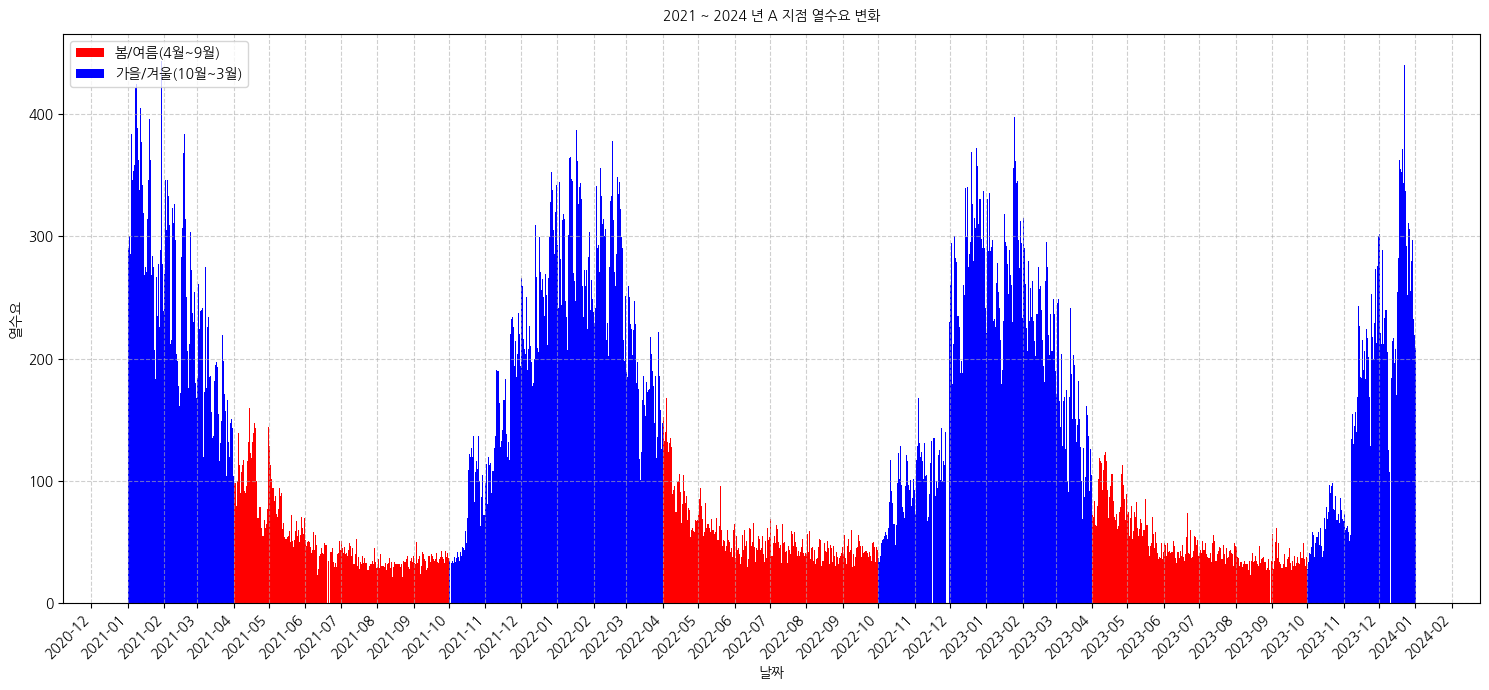

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import matplotlib.font_manager as fm

font_path = 'C:\\WINDOWS\\Fonts\\NanumGothic.ttf'
fontprop = fm.FontProperties(fname=font_path)

# 1. 데이터 전처리 (datetime 변환)
df['datetime'] = pd.to_datetime(location_dict['A']['train_heat.tm'], format='%Y%m%d%H', errors='coerce')
df.dropna(subset=['datetime'], inplace=True) # 변환 실패 데이터 제거
df['month'] = df['datetime'].dt.month # 월 정보 추출

# 2. 시각화
plt.figure(figsize=(15, 7))

# 3. 색상 설정
colors = ['red' if 4 <= m <= 9 else 'blue' for m in df['month']]

# 4. 그래프
plt.bar(df['datetime'], location_dict['A']['train_heat.heat_demand'], width=0.8, color=colors)

# X축 날짜 포맷 설정
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1)) # 월별 주 눈금
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) # YYYY-MM 형식
plt.xticks(rotation=45, ha='right') # 레이블 회전

# 그래프 제목 및 축 레이블
plt.title('2021 ~ 2024 년 A 지점 열수요 변화', fontsize=100, pad=10, fontproperties=fontprop)
plt.xlabel('날짜', fontproperties=fontprop)
plt.ylabel('열수요', fontproperties=fontprop)

# 범례 추가
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='봄/여름(4월~9월)'),
    Patch(facecolor='blue', label='가을/겨울(10월~3월)')
]
plt.legend(handles=legend_elements, loc='upper left', prop=fontprop)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [57]:
!pip install holidays

   ---------------------------------------- 0.0/954.8 kB ? eta -:--:--
   --------------------------------------- 954.8/954.8 kB 14.7 MB/s eta 0:00:00


In [61]:
# 날짜 파생변수 생성
df3 = df2.copy()

import pandas as pd
from datetime import datetime
import holidays # 공휴일 정보 라이브러리

# 1. 'train_heat.tm' 열을 datetime 객체로 변환
# errors='coerce': 변환 불가능한 값은 NaT (Not a Time)로 처리하여 에러 방지
df3['datetime_obj'] = pd.to_datetime(df3['train_heat.tm'], format='%Y%m%d%H', errors='coerce')

# 2. 'weekend' 파생열 추가 (토, 일, 공휴일)
# 한국 공휴일 설정
kr_holidays = holidays.KR()

def is_weekend_or_holiday(date_obj):
    if pd.isna(date_obj): # NaT 값 처리
        return 0
    # 주말 (토요일: 5, 일요일: 6) 확인
    if date_obj.weekday() >= 5: # Monday is 0 and Sunday is 6
        return 1
    # 공휴일 확인
    if date_obj in kr_holidays:
        return 1
    return 0

df3['weekend'] = df3['datetime_obj'].apply(is_weekend_or_holiday)

# 3. 'month' 파생열 추가
df3['month'] = df3['datetime_obj'].dt.month # .dt.month를 사용하여 월 정보 추출

# 4. 필요 없는 열 제거
df3 = df3.drop(columns=['train_heat.tm'])
df3 = df3.drop(columns=['datetime_obj'])


print("\n--- 파생열 추가 및 날짜 열 제거 후 데이터프레임 ---")
df3


--- 파생열 추가 및 날짜 열 제거 후 데이터프레임 ---


,train_heat.branch_id,train_heat.ta,train_heat.wd,train_heat.ws,train_heat.rn_day,train_heat.rn_hr1,train_heat.hm,train_heat.si,train_heat.ta_chi,train_heat.heat_demand,weekend,month
8,A,-8.6,88.9,1.2,0.0,0.0,63.8,0.00,-8.4,284,1,1
9,A,-7.4,71.6,1.3,0.0,0.0,61.2,0.27,-7.5,290,1,1
10,A,-4.7,157.5,0.5,0.0,0.0,50.4,0.76,-5.3,285,1,1
11,A,-2.6,184.2,0.9,0.0,0.0,41.5,1.40,-3.1,277,1,1
12,A,-2.2,232.4,1.2,0.0,0.0,46.1,1.74,-1.6,269,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
499292,S,4.4,288.7,2.6,2.5,0.0,86.6,0.57,2.0,25,1,12
499293,S,4.4,287.0,2.4,2.5,0.0,86.7,0.50,2.6,26,1,12
499294,S,4.9,302.5,2.2,2.5,0.0,84.8,0.31,3.0,29,1,12
499295,S,4.4,284.1,1.2,2.5,0.0,87.3,0.16,4.4,30,1,12


[<Axes: xlabel='train_heat.branch_id', ylabel='Count'>,
 <Axes: xlabel='train_heat.ta', ylabel='Count'>,
 <Axes: xlabel='train_heat.wd', ylabel='Count'>,
 <Axes: xlabel='train_heat.ws', ylabel='Count'>,
 <Axes: xlabel='train_heat.rn_day', ylabel='Count'>,
 <Axes: xlabel='train_heat.rn_hr1', ylabel='Count'>,
 <Axes: xlabel='train_heat.hm', ylabel='Count'>,
 <Axes: xlabel='train_heat.si', ylabel='Count'>,
 <Axes: xlabel='train_heat.ta_chi', ylabel='Count'>,
 <Axes: xlabel='train_heat.heat_demand', ylabel='Count'>,
 <Axes: xlabel='weekend', ylabel='Count'>,
 <Axes: xlabel='month', ylabel='Count'>]

C:\Users\jioyu\AppData\Local\Temp\ipykernel_11400\2725576833.py:5: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
C:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


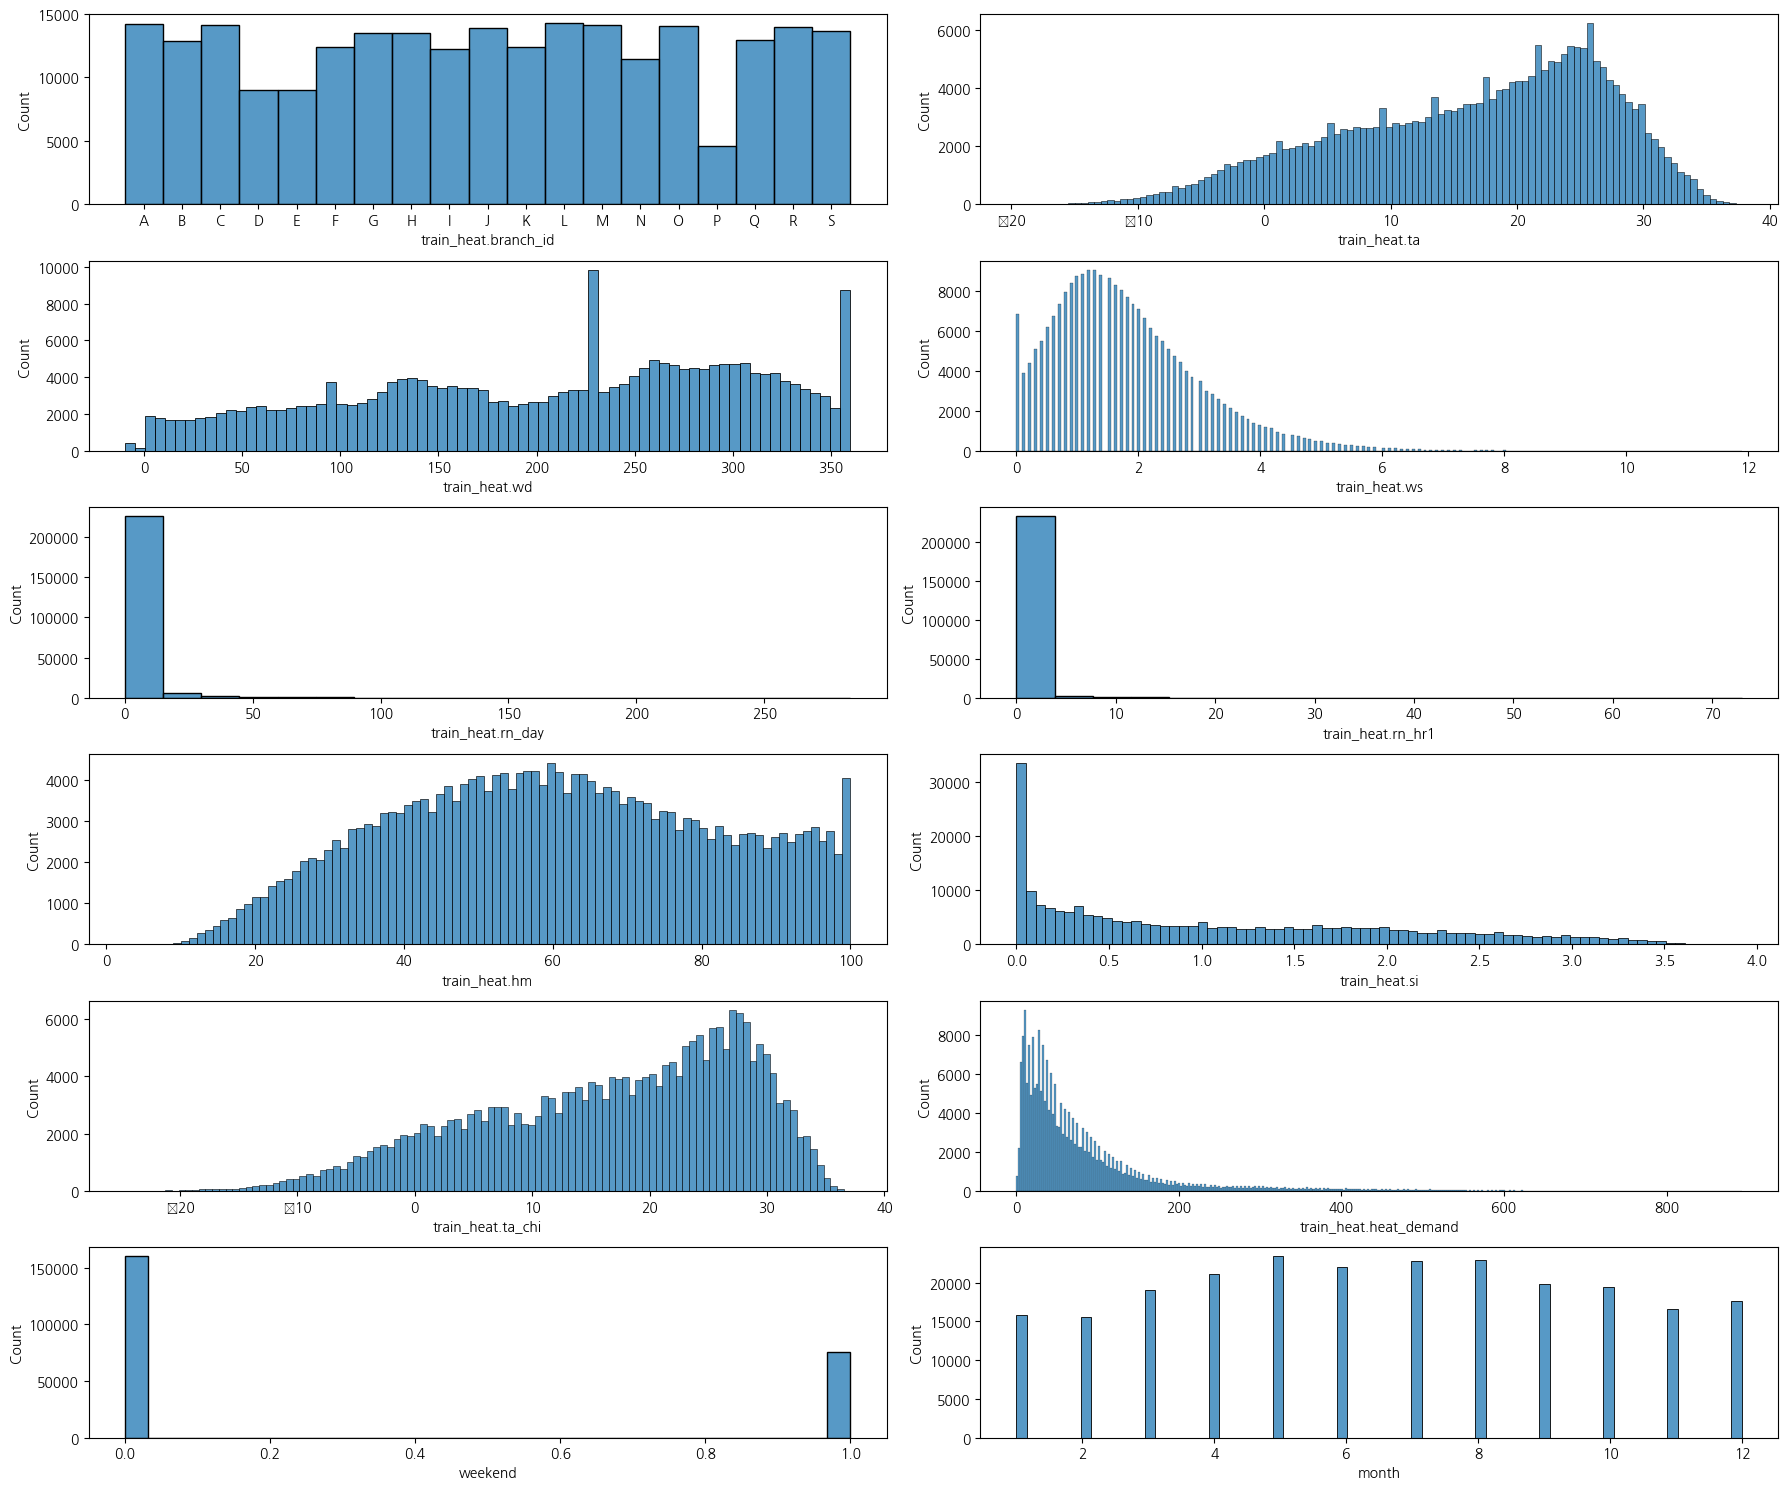

In [65]:
# 정규분포 확인
import seaborn as sns
fig, axes = plt.subplots(6, 2, figsize=(18, 15))
list(map(lambda ax, col: sns.histplot(x=col, ax=ax, data=df3), axes.ravel(), df3.columns))
plt.tight_layout()
plt.show()

[<Axes: ylabel='train_heat.branch_id'>,
 <Axes: ylabel='train_heat.ta'>,
 <Axes: ylabel='train_heat.wd'>,
 <Axes: ylabel='train_heat.ws'>,
 <Axes: ylabel='train_heat.rn_day'>,
 <Axes: ylabel='train_heat.rn_hr1'>,
 <Axes: ylabel='train_heat.hm'>,
 <Axes: ylabel='train_heat.si'>,
 <Axes: ylabel='train_heat.ta_chi'>,
 <Axes: ylabel='train_heat.heat_demand'>,
 <Axes: ylabel='weekend'>,
 <Axes: ylabel='month'>]

C:\Users\jioyu\AppData\Local\Temp\ipykernel_11400\2872760776.py:4: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
C:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


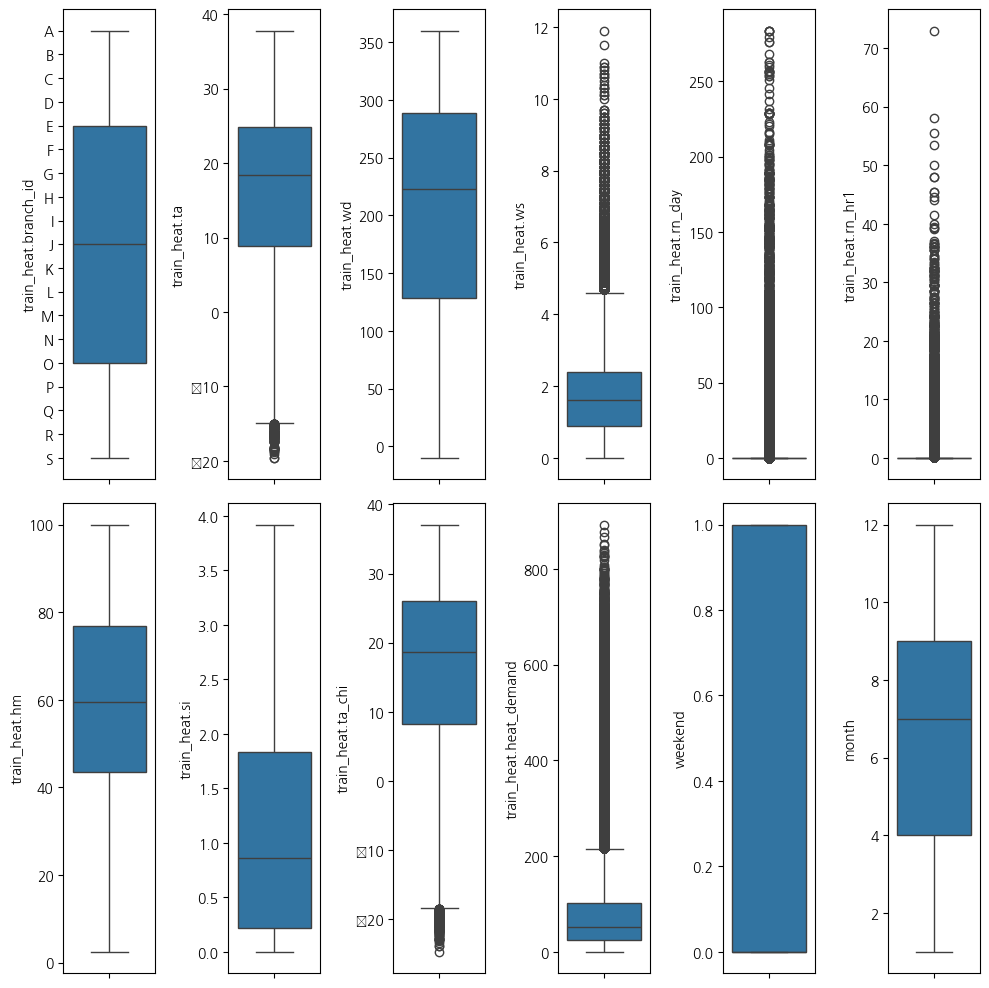

In [77]:
# 이상치 확인
fig, axes = plt.subplots(2, 6, figsize=(10, 10))
list(map(lambda ax, col: sns.boxplot(y=col, ax=ax, data=df3), axes.ravel(), df3.columns))
plt.tight_layout()
plt.show()

In [83]:
# 상관계수 검사
df3 = df3.drop('train_heat.branch_id', axis=1)
df3_corr_mat = df3.corr()
df3_corr_mat.loc['train_heat.heat_demand'].drop('train_heat.heat_demand').sort_values(ascending=False)

train_heat.wd        0.042955
weekend             -0.022714
train_heat.rn_hr1   -0.038813
train_heat.rn_day   -0.059967
train_heat.ws       -0.072619
train_heat.si       -0.094446
month               -0.143450
train_heat.hm       -0.179579
train_heat.ta       -0.545447
train_heat.ta_chi   -0.547955
Name: train_heat.heat_demand, dtype: float64

In [85]:
df3_corr_mat.loc['train_heat.heat_demand'].drop('train_heat.heat_demand').sort_values(ascending=True)

train_heat.ta_chi   -0.547955
train_heat.ta       -0.545447
train_heat.hm       -0.179579
month               -0.143450
train_heat.si       -0.094446
train_heat.ws       -0.072619
train_heat.rn_day   -0.059967
train_heat.rn_hr1   -0.038813
weekend             -0.022714
train_heat.wd        0.042955
Name: train_heat.heat_demand, dtype: float64

C:\Anaconda3\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  self._figure.tight_layout(*args, **kwargs)


C:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


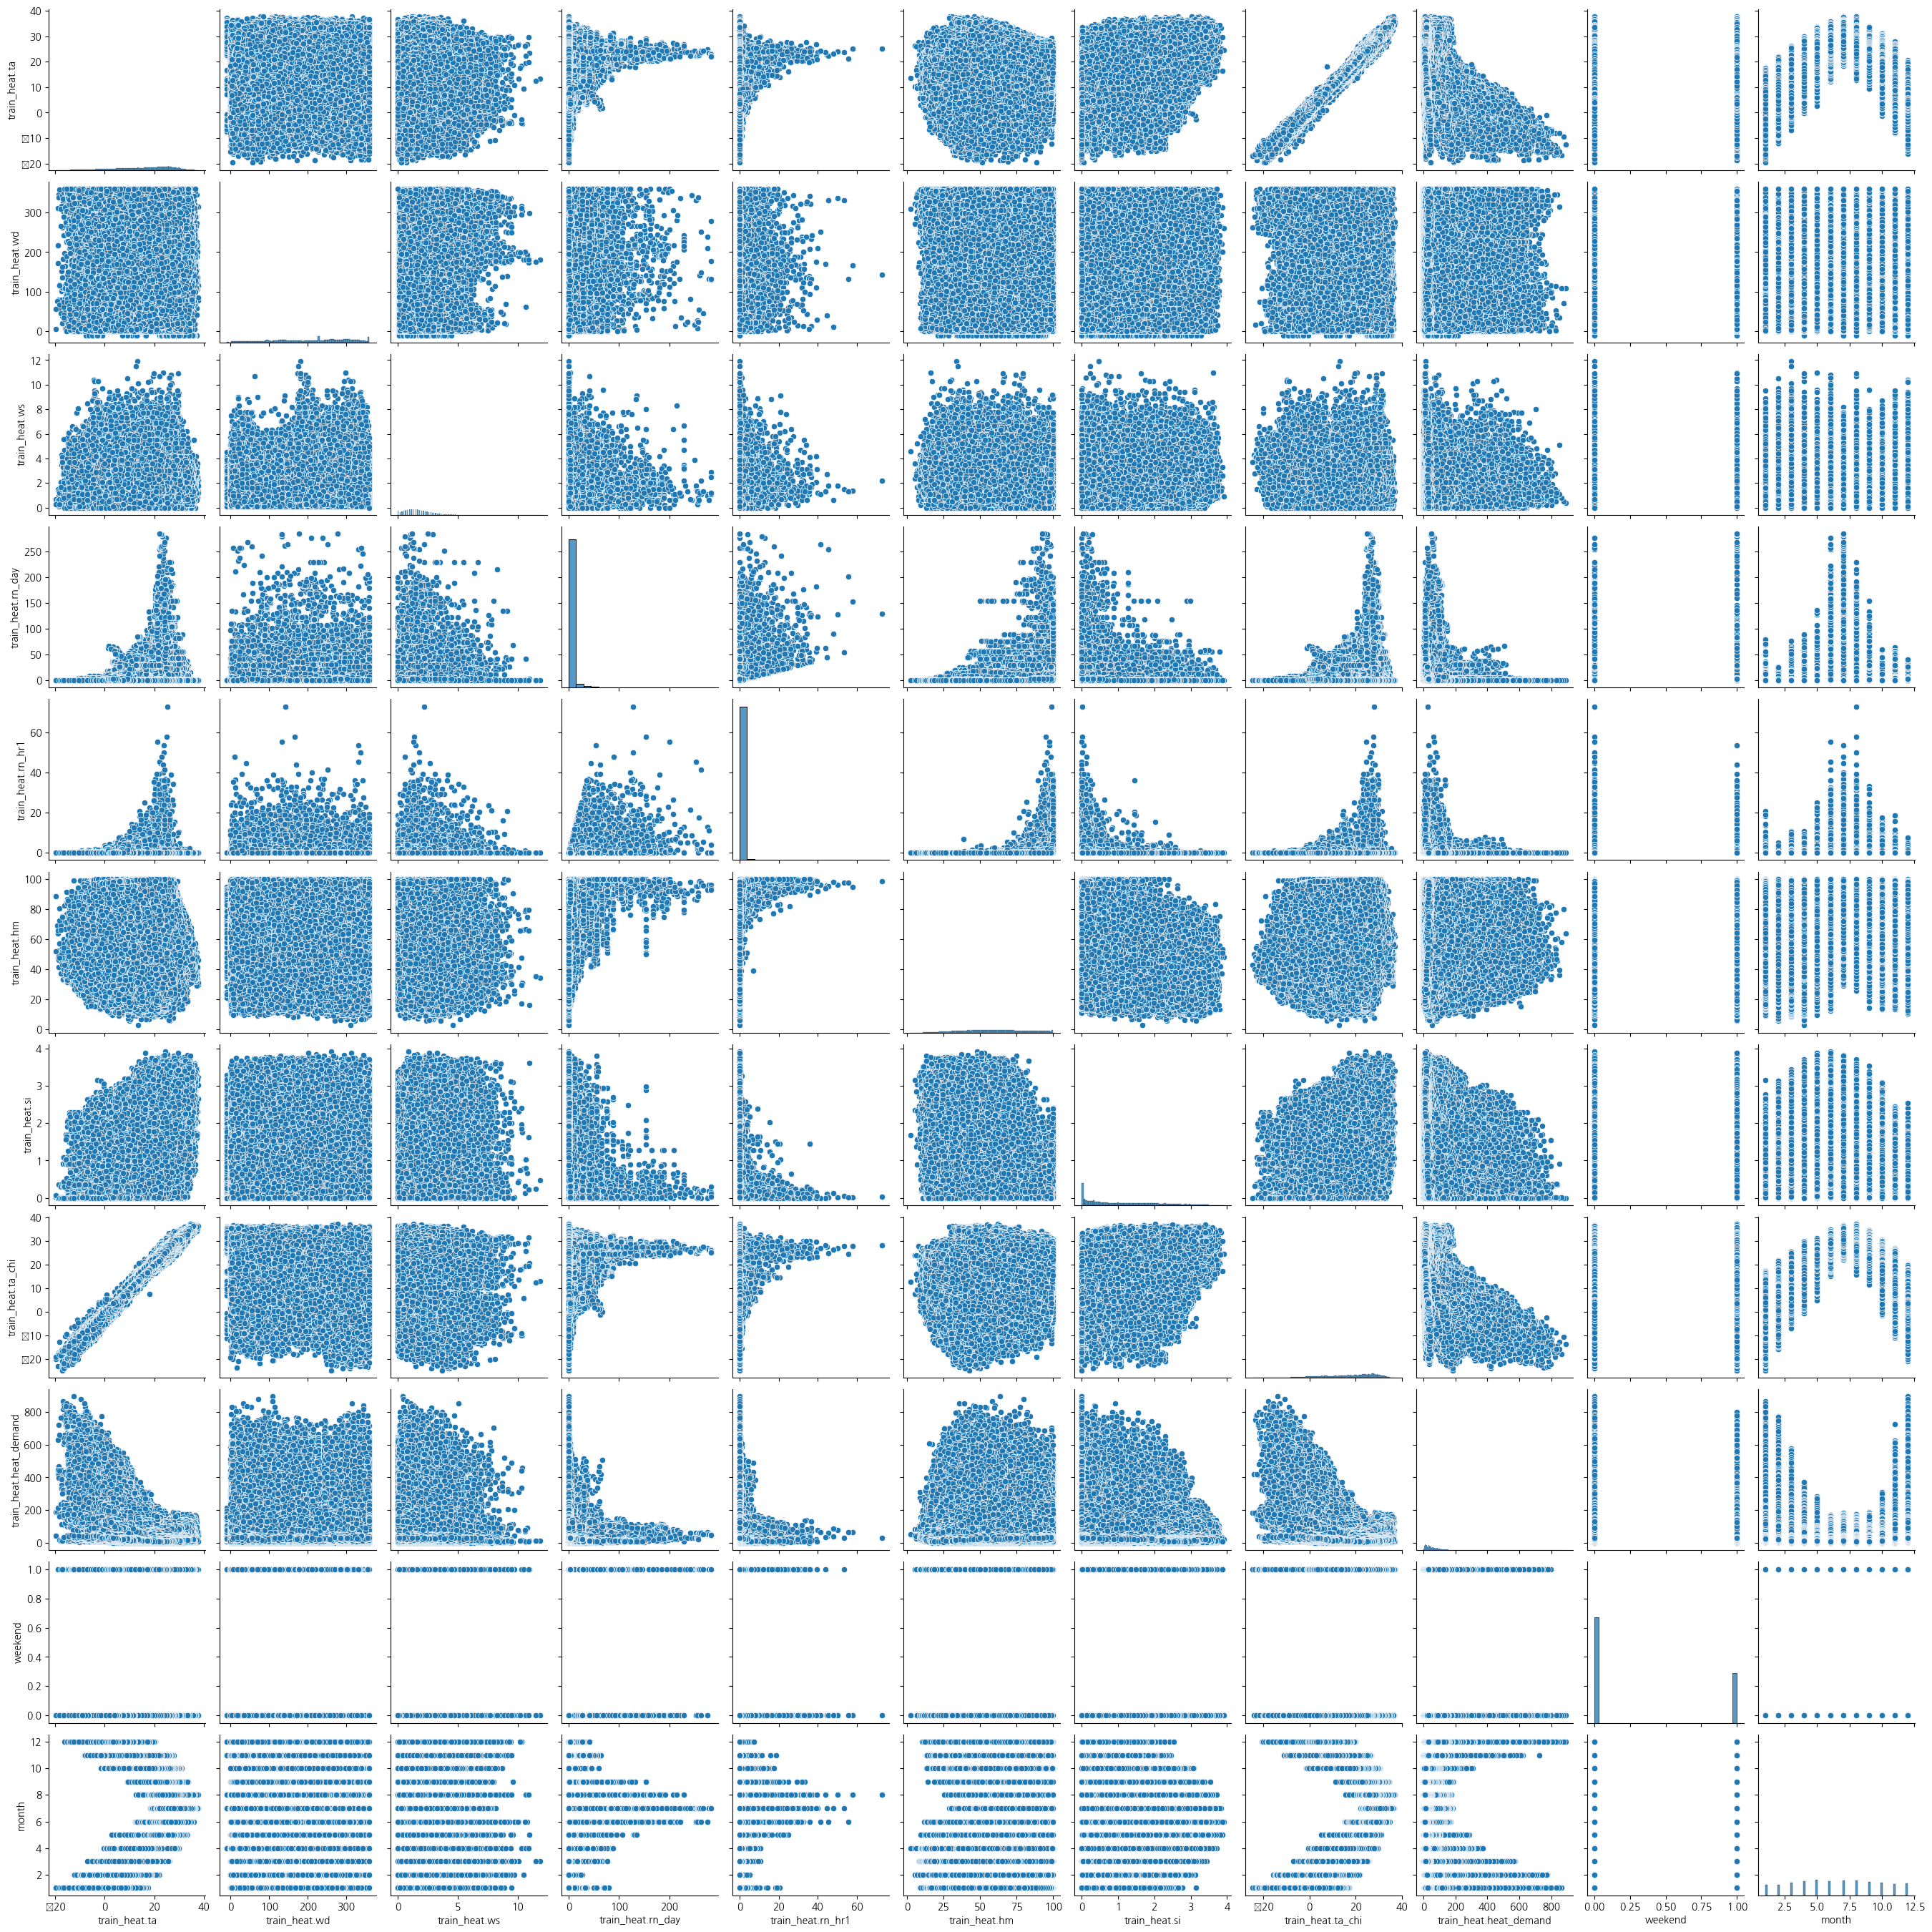

In [87]:
# 상관계수 검사 - 산점도
import seaborn as sns
sns.pairplot(df3)
plt.show()

In [89]:
# Target, Features 분리
x = df3.iloc[:, :-1] # feature
y = df3['train_heat.heat_demand'] # target

<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, '변수간 히트맵')

C:\Anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.draw()


<Axes: title={'center': '변수간 히트맵'}>

C:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


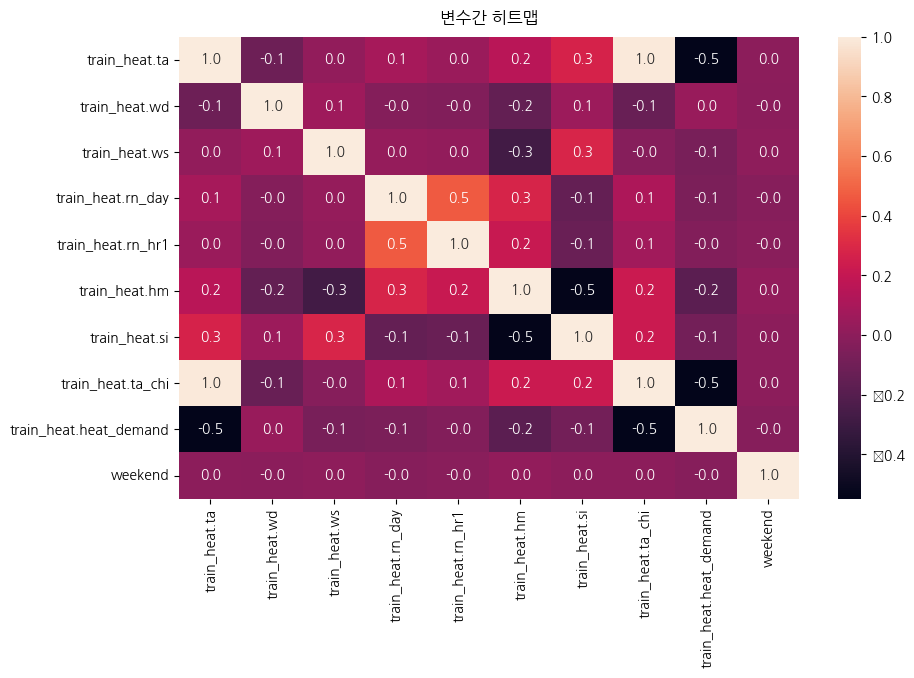

In [95]:
# 상관계수 검사 - 히트맵
plt.figure(figsize=(10,6))
plt.title('변수간 히트맵', pad=10)
sns.heatmap(x.corr(), annot=True, fmt='.1f')
plt.show()

In [97]:
# 다중공선성 검사
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()
vif_df['vif'] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
vif_df['features'] = x.columns
vif_df = vif_df.sort_values("vif").reset_index(drop=True) # 다시 0부터 
vif_df

,vif,features
0,1.318131,train_heat.rn_hr1
1,1.407297,train_heat.rn_day
2,1.464053,weekend
3,2.062332,train_heat.heat_demand
4,3.495960,train_heat.ws
5,3.500817,train_heat.si
6,4.662483,train_heat.wd
7,7.228609,train_heat.hm
8,303.748114,train_heat.ta_chi
9,325.443485,train_heat.ta
